# VisionInspect — Anomalib Training (Phase 1)

Trains the Phase 1 Anomalib baseline on a single MVTec AD category.

**Reproducibility note:** the cell below is tagged `parameters`, so this notebook can be executed
headlessly and reproducibly via `papermill`, e.g.:

```bash
papermill notebooks/train_anomalib.ipynb notebooks/executed/train_anomalib_bottle.ipynb \
    -p category bottle -p model_name patchcore
```

**Known environment issue:** if you hit a `RecursionError` inside `rich`/`traitlets`
(`file_proxy.py`, `console.py`) during training, this is a display bug, not a training bug --
Lightning's rich progress bar can get double-wrapped by some notebook environments' own output
capture (seen in VS Code notebooks; more likely on newer Python versions like 3.14). It's disabled
by default below (`enable_progress_bar = False`); flip it on if your environment doesn't hit this.

**API note:** current Anomalib (2.x) moved `image_size` off the datamodule and onto each model's
`configure_pre_processor()` -- `train.py`'s `build_model()` handles this; the datamodule itself is
built with no `image_size` argument.

In [5]:
# Parameters (overridable via papermill -p)
data_root = "/home/zubair/AI Development Directory/visioninspect/data/raw"
category = "bottle"
model_name = "patchcore"  # one of: patchcore, padim, efficientad (efficientad needs batch_size=1)
image_size = 224
batch_size = 4
max_epochs = 1
output_dir = "../models"
mlflow_experiment = "visioninspect-anomalib"
mlflow_tracking_uri = "sqlite:///../experiments/mlflow.db"
enable_progress_bar = False

In [6]:
import sys
sys.path.append("../src")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from anomalib_pipeline.train import train
from anomalib_pipeline.prepare_data import verify_category

## 1. Verify dataset structure

Confirms the native MVTec AD split (normal-only train, mixed test, ground-truth masks) is intact
before training. If your download 404s from the official MVTec endpoint, see `prepare_data.py`
for a HuggingFace mirror fallback.

In [7]:
category_root = Path(data_root) / category
result = verify_category(category_root)
print(result)
assert not result["issues"], f"Dataset issues found: {result['issues']}"

{'counts': {'train_good': 209, 'test_good': 20, 'test_anomalous': 63, 'masks': 63}, 'issues': []}


## 2. Train

Logs params, metrics, and the checkpoint to MLflow. The printed `run_id` ties the checkpoint
saved under `models/` back to this exact run -- record it if you promote this checkpoint
downstream (e.g. in a provenance note alongside the file).

In [8]:
result = train(
    data_root=Path(data_root),
    category=category,
    model_name=model_name,
    image_size=image_size,
    batch_size=batch_size,
    max_epochs=max_epochs,
    output_dir=Path(output_dir),
    mlflow_experiment=mlflow_experiment,
    mlflow_tracking_uri=mlflow_tracking_uri,
    enable_progress_bar=enable_progress_bar,
)
result

2026/08/11 13:56:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 13:56:25 INFO mlflow.store.db.utils: Updating database tables
2026/08/11 13:56:29 INFO mlflow.tracking.fluent: Experiment with name 'visioninspect-anomalib' does not exist. Creating a new experiment.
/home/zubair/.pyenv/versions/venv312/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Co

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.450                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

/home/zubair/.pyenv/versions/venv312/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/zubair/.pyenv/versions/venv312/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 174 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.
Selecting Coreset Indices.: 100%|██████████| 16384/16384 [00:35<00:00, 457.54it/s]
`Trainer.fit` stopped: `max_epochs=1` reached.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            1.0            │
│       image_F1Score       │    0.9919999837875366     │
│        pixel_AUROC        │     0.984029233455658     │
│       pixel_F1Score       │    0.7141480445861816     │
└───────────────────────────┴───────────────────────────┘

`weights_only` was not set, defaulting to `False`.



[done] run_id=6ea08555db924ca393038bdb500d891d
[done] checkpoint saved to ../models/patchcore_bottle.ckpt
[done] IMPORTANT: record this run_id next to the checkpoint -- it is how the shipped model is traced back to its training run.


{'run_id': '6ea08555db924ca393038bdb500d891d',
 'checkpoint': '../models/patchcore_bottle.ckpt',
 'test_results': [{'image_AUROC': 1.0,
   'image_F1Score': 0.9919999837875366,
   'pixel_AUROC': 0.984029233455658,
   'pixel_F1Score': 0.7141480445861816}]}

## 3. Inspect test metrics

Image-level AUROC, pixel-level AUROC, and PRO score -- the anomaly-detection-appropriate metrics
(not precision/recall/mAP, which assume bounding boxes).

In [9]:
result["test_results"]

[{'image_AUROC': 1.0,
  'image_F1Score': 0.9919999837875366,
  'pixel_AUROC': 0.984029233455658,
  'pixel_F1Score': 0.7141480445861816}]

## 4. Inference sanity check

Runs the trained model on a single test image and visualizes the original image, the predicted
anomaly heatmap, and the thresholded segmentation mask side by side.

/home/zubair/.pyenv/versions/venv312/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Restoring states from the checkpoint path at /home/zubair/AI Development Directory/visioninspect_v112/models/patchcore_bottle.ckpt
/home/zubair/.pyenv/versions/venv312/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: The dirpath has changed from '/home/zubair/AI Development Directory/visioninspect_v112/notebooks/results/Patchcore/MVTecAD/bottle/v0/weig

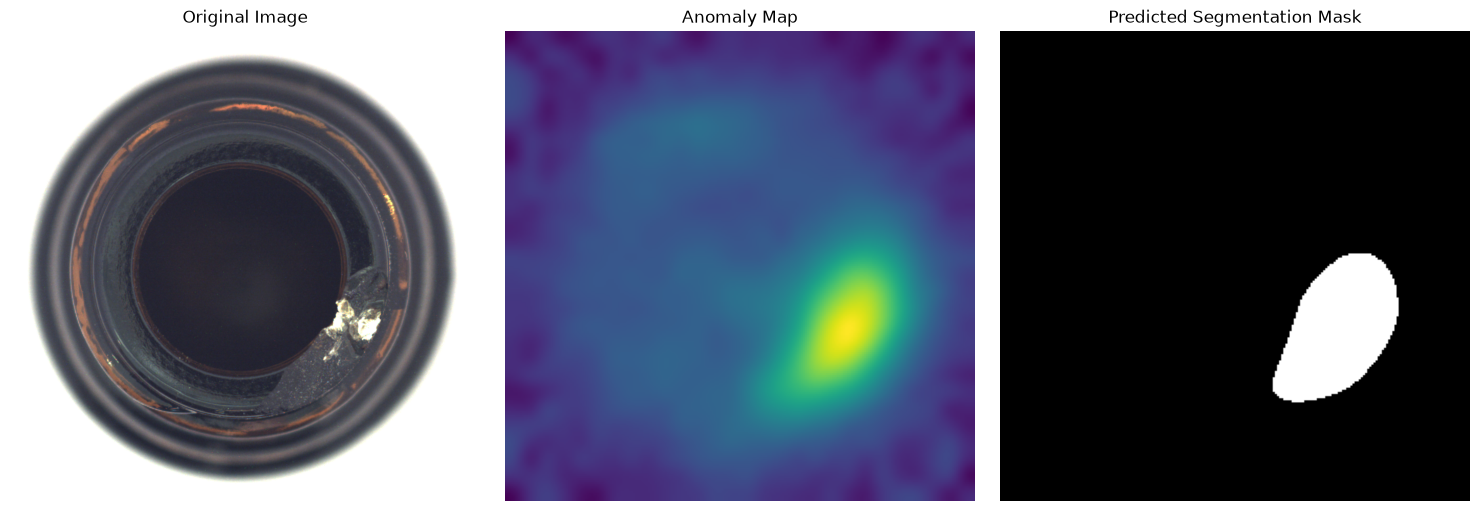

Predicted image score: 0.9951


In [10]:
from anomalib.data import PredictDataset
from anomalib.engine import Engine
from anomalib.pre_processing import PreProcessor
from torch.serialization import safe_globals
from anomalib_pipeline.train import MODEL_REGISTRY

checkpoint_path = result["checkpoint"]
# weights_only=False + safe_globals([PreProcessor]): PyTorch 2.6+ defaults torch.load's
# weights_only to True, which blocks unpickling Anomalib's PreProcessor class embedded
# in the checkpoint. Fine to trust here since it's a checkpoint you just trained yourself.
with safe_globals([PreProcessor]):
    model = MODEL_REGISTRY[model_name].load_from_checkpoint(checkpoint_path, weights_only=False)

# Pick one anomalous test image for a sanity-check visualization
test_dir = Path(data_root) / category / "test"
defect_dirs = [d for d in test_dir.iterdir() if d.is_dir() and d.name != "good"]
sample_image_path = next(defect_dirs[0].glob("*.png")) if defect_dirs else None

if sample_image_path is not None:
    predict_dataset = PredictDataset(path=sample_image_path, image_size=(image_size, image_size))
    engine = Engine(enable_progress_bar=enable_progress_bar)
    predictions = engine.predict(model=model, dataset=predict_dataset, ckpt_path=checkpoint_path)
    pred = predictions[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(Image.open(sample_image_path))
    axes[0].set_title("Original Image")
    axes[1].imshow(np.array(pred.anomaly_map.squeeze()))
    axes[1].set_title("Anomaly Map")
    axes[2].imshow(np.array(pred.pred_mask.squeeze()), cmap="gray")
    axes[2].set_title("Predicted Segmentation Mask")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Predicted image score: {float(pred.pred_score):.4f}")
else:
    print("No anomalous test images found for this category.")

## 5. Error analysis: hardest examples

Runs prediction across the full test set and surfaces the most difficult cases -- normal images
with the highest anomaly scores (false-positive risks) and anomalous images with the lowest scores
(false-negative risks). This is the single most useful diagnostic for deciding whether a model is
actually production-ready, versus just posting a good aggregate AUROC.

In [11]:
test_good_dir = test_dir / "good"
all_test_images = list(test_good_dir.glob("*.png")) + [
    p for d in defect_dirs for p in d.glob("*.png")
]

records = []
engine = Engine(enable_progress_bar=enable_progress_bar)
for img_path in all_test_images:
    ds = PredictDataset(path=img_path, image_size=(image_size, image_size))
    pred = engine.predict(model=model, dataset=ds, ckpt_path=checkpoint_path)[0]
    records.append({
        "path": str(img_path),
        "true_label": "normal" if img_path.parent.name == "good" else "anomaly",
        "score": float(pred.pred_score),
    })

results_df = pd.DataFrame(records)
results_df.head()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Restoring states from the checkpoint path at /home/zubair/AI Development Directory/visioninspect_v112/models/patchcore_bottle.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/zubair/AI Development Directory/visioninspect_v112/models/patchcore_bottle.ckpt
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at /home/zubair/AI Development Directory/visioninspect_v112/models/patchcore_bottle.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the ch

,path,true_label,score
0,/home/zubair/AI Development Directory/visionin...,normal,0.342066
1,/home/zubair/AI Development Directory/visionin...,normal,0.227681
2,/home/zubair/AI Development Directory/visionin...,normal,0.333138
3,/home/zubair/AI Development Directory/visionin...,normal,0.238294
4,/home/zubair/AI Development Directory/visionin...,normal,0.274098


In [12]:
# Hardest "good" images: normal images the model scored as most anomalous
hardest_good = results_df[results_df["true_label"] == "normal"].sort_values("score", ascending=False).head(5)
print("Hardest normal images (highest false-positive risk):")
display(hardest_good)

# Hardest anomalous images: defective images the model scored as least anomalous
hardest_anomalous = results_df[results_df["true_label"] == "anomaly"].sort_values("score", ascending=True).head(5)
print("Hardest anomalous images (highest false-negative risk):")
display(hardest_anomalous)

Hardest normal images (highest false-positive risk):


,path,true_label,score
7,/home/zubair/AI Development Directory/visionin...,normal,0.342554
0,/home/zubair/AI Development Directory/visionin...,normal,0.342066
2,/home/zubair/AI Development Directory/visionin...,normal,0.333138
11,/home/zubair/AI Development Directory/visionin...,normal,0.312546
9,/home/zubair/AI Development Directory/visionin...,normal,0.305249


Hardest anomalous images (highest false-negative risk):


,path,true_label,score
59,/home/zubair/AI Development Directory/visionin...,anomaly,0.499953
43,/home/zubair/AI Development Directory/visionin...,anomaly,0.538358
44,/home/zubair/AI Development Directory/visionin...,anomaly,0.569699
49,/home/zubair/AI Development Directory/visionin...,anomaly,0.622150
42,/home/zubair/AI Development Directory/visionin...,anomaly,0.623987


In [ ]:
# export PatchCore models trained on MVTec AD dataset to ONNX format, path to best models in .vinsioninspec_v112/models
output_dir = Path("./models/patchcore")

